In [2]:
# https://www.kaggle.com/code/janiobachmann/bank-marketing-campaign-opening-a-term-deposit/notebook
import pandas as pd
bank_df = pd.read_csv("bank.csv")
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Exploration Data Analysis

In [22]:
telephone_df = bank_df[bank_df['contact']=='telephone']

job_counts = telephone_df['job'].value_counts()         
telephone_df['marital'].value_counts()
deposit_counts = telephone_df['deposit'].value_counts() 
print("job counts", job_counts)
print("deposit counts", deposit_counts)

job counts job
retired          170
management       127
blue-collar      115
admin.            84
technician        79
services          46
student           31
housemaid         31
self-employed     30
entrepreneur      26
unemployed        24
unknown           11
Name: count, dtype: int64
deposit counts deposit
yes    390
no     384
Name: count, dtype: int64


In [23]:
cellular_df = bank_df[bank_df['contact']=='cellular']

job_counts = cellular_df['job'].value_counts()
cellular_df['marital'].value_counts()
deposit_counts = cellular_df['deposit'].value_counts() 
print("job counts", job_counts)
print("deposit counts", deposit_counts)

job counts job
management       2066
technician       1392
blue-collar      1141
admin.            972
services          627
retired           518
student           311
self-employed     287
unemployed        275
entrepreneur      219
housemaid         185
unknown            49
Name: count, dtype: int64
deposit counts deposit
yes    4369
no     3673
Name: count, dtype: int64


previous
0     8324
1      887
2      693
3      435
4      244
5      165
6      117
7       77
8       60
9       34
10      30
11      23
12      16
17      11
13      11
14       6
15       5
19       4
23       2
16       2
27       2
20       2
58       1
22       1
30       1
29       1
55       1
26       1
21       1
41       1
40       1
28       1
18       1
37       1
Name: count, dtype: int64

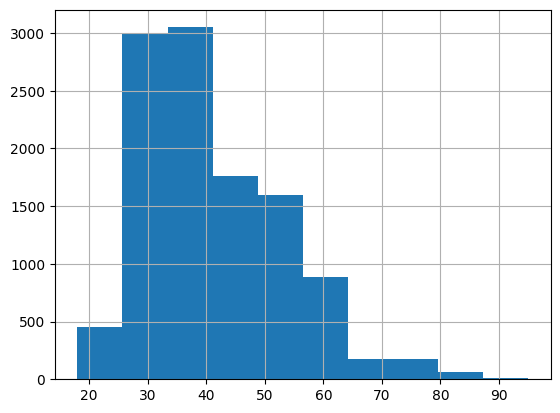

In [ ]:
bank_df['age'].hist()
cellular_df = bank_df['contact']=='cellular'

bank_df['job'].value_counts()
bank_df['campaign'].value_counts()
bank_df['previous'].value_counts()

In [25]:
from scipy.stats import fisher_exact
from scipy.stats import  chisquare
import numpy as np

contingency_table = pd.crosstab(bank_df['contact'], bank_df['deposit'])
res = fisher_exact(contingency_table)
print(res.pvalue)

cellular_no = (cellular_df['deposit']=='no').sum()
cellular_yes = (cellular_df['deposit']=='yes').sum()

telephone_no_rate = (telephone_df['deposit']=='no').mean()
f_obs = np.array([cellular_no, cellular_yes])     
n = len(cellular_df)
f_exp = np.array([n*telephone_no_rate, (1-telephone_no_rate)*n])
res = chisquare(f_obs, f_exp)
print(res.pvalue)

0.0001
1.5922195737727037e-12
